In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fnv2024/Vegetable Prices 2022.csv
/kaggle/input/fnv2024/Fruit Prices 2022.csv


<div style="border-radius: 20px; border: 2px solid #ca1f7b; padding: 25px; background: linear-gradient(145deg, #f06292, #ca1f7b); text-align: center; box-shadow: 0px 4px 12px rgba(0, 0, 0, 0.4), 0px 6px 20px rgba(0, 0, 0, 0.19); transform: perspective(1000px) rotateX(5deg) rotateY(-5deg); transition: transform 0.5s ease-in-out;">
    <h1 style="color: white; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.4); font-weight: bold; margin-bottom: 15px; font-size: 36px;">
        Welcome!
    </h1>
    <p style="color: white; font-size: 20px; margin: 15px 0; font-family: 'Arial', sans-serif;">
        Hi there! I'm Himel Sarder, a passionate Data Scientist and ML Engineer in training. I'm exploring the world of AI, diving deep into various concepts and techniques to improve my skills. Join me as we embark on this exciting journey to learn and grow together in the AI field.
    </p>
    <p style="color: white; font-size: 18px; font-style: italic; margin: 15px 0;">
        "Community empowers growth through shared knowledge and mutual support."
    </p>
    <h2 style="color: white; margin-top: 25px; font-size: 32px; font-weight: bold;">Contact Information</h2>
    <table style="width: 100%; margin-top: 20px; border-collapse: collapse;">
        <tr>
            <th style="color: white; font-size: 20px; padding: 12px; border-bottom: 2px solid #ca1f7b; background-color: rgba(255, 255, 255, 0.2);">Name</th>
            <th style="color: white; font-size: 20px; padding: 12px; border-bottom: 2px solid #ca1f7b; background-color: rgba(255, 255, 255, 0.2);">Email</th>
            <th style="color: white; font-size: 20px; padding: 12px; border-bottom: 2px solid #ca1f7b; background-color: rgba(255, 255, 255, 0.2);">LinkedIn</th>
            <th style="color: white; font-size: 20px; padding: 12px; border-bottom: 2px solid #ca1f7b; background-color: rgba(255, 255, 255, 0.2);">GitHub</th>
            <th style="color: white; font-size: 20px; padding: 12px; border-bottom: 2px solid #ca1f7b; background-color: rgba(255, 255, 255, 0.2);">Kaggle</th>
        </tr>
        <tr>
            <td style="font-size: 18px; padding: 12px; color: white;">Himel Sarder</td>
            <td style="font-size: 18px; padding: 12px; color: white;">info.himelcse@gmail.com</td>
            <td style="font-size: 18px; padding: 12px;">
                <a href="https://www.linkedin.com/in/himel-sarder/" target="_blank" style="text-decoration: none;">
                    <img src="https://img.shields.io/badge/LinkedIn-ca1f7b.svg?style=for-the-badge&logo=LinkedIn&logoColor=white" alt="LinkedIn Badge" style="border-radius: 5px; transition: transform 0.3s ease;">
                </a>
            </td>
            <td style="font-size: 18px; padding: 12px;">
                <a href="https://github.com/Himel-Sarder" target="_blank" style="text-decoration: none;">
                    <img src="https://img.shields.io/badge/GitHub-ca1f7b.svg?style=for-the-badge&logo=GitHub&logoColor=white" alt="GitHub Badge" style="border-radius: 5px; transition: transform 0.3s ease;">
                </a>
            </td>
            <td style="font-size: 18px; padding: 12px;">
                <a href="https://www.kaggle.com/himelsarder" target="_blank" style="text-decoration: none;">
                    <img src="https://img.shields.io/badge/Kaggle-ca1f7b.svg?style=for-the-badge&logo=Kaggle&logoColor=white" alt="Kaggle Badge" style="border-radius: 5px; transition: transform 0.3s ease;">
                </a>
            </td>
        </tr>
    </table>
</div>


In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

# Load dataset

In [4]:
df = pd.read_csv("/kaggle/input/fnv2024/Fruit Prices 2022.csv")

# Display first few rows

In [5]:
print("Dataset Preview:")
df.head()

Dataset Preview:


,Fruit,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,CupEquivalentPrice
0,Apples,Fresh,1.8541,per pound,0.90,0.2425,pounds,0.4996
1,"Apples, applesauce",Canned,1.1705,per pound,1.00,0.5401,pounds,0.6323
2,"Apples, ready-to-drink",Juice,0.8699,per pint,1.00,8.0000,fluid ounces,0.4349
3,"Apples, frozen concentrate",Juice,0.6086,per pint,1.00,8.0000,fluid ounces,0.3043
4,Apricots,Fresh,3.6162,per pound,0.93,0.3638,pounds,1.4145


# Handling categorical variables

In [6]:
le = LabelEncoder()
df['Fruit'] = le.fit_transform(df['Fruit'])
df['Form'] = le.fit_transform(df['Form'])
df['RetailPriceUnit'] = le.fit_transform(df['RetailPriceUnit'])
df['CupEquivalentUnit'] = le.fit_transform(df['CupEquivalentUnit'])

In [7]:
df.head()

,Fruit,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,CupEquivalentPrice
0,0,2,1.8541,1,0.90,0.2425,1,0.4996
1,1,0,1.1705,1,1.00,0.5401,1,0.6323
2,3,4,0.8699,0,1.00,8.0000,0,0.4349
3,2,4,0.6086,0,1.00,8.0000,0,0.3043
4,4,2,3.6162,1,0.93,0.3638,1,1.4145


# Define features and target variable (Predicting CupEquivalentPrice)

In [8]:
X = df.drop(columns=['CupEquivalentPrice'])
y = df['CupEquivalentPrice']

In [9]:
X.head()

,Fruit,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit
0,0,2,1.8541,1,0.90,0.2425,1
1,1,0,1.1705,1,1.00,0.5401,1
2,3,4,0.8699,0,1.00,8.0000,0
3,2,4,0.6086,0,1.00,8.0000,0
4,4,2,3.6162,1,0.93,0.3638,1


# Split data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train.shape, y_train.shape

((49, 7), (49,))

# Train model without feature construction

In [12]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate without feature construction

In [13]:
mae_without = mean_absolute_error(y_test, y_pred)
r2_without = r2_score(y_test, y_pred)

mae_without

0.41209123076923065

In [14]:
r2_without

0.31250065211129907

# Feature Construction

In [15]:
df['UsablePrice'] = df['RetailPrice'] / df['Yield']
df['CostEfficiency'] = df['Yield'] / df['CupEquivalentPrice']
df['Form_Category'] = df['Form']

In [16]:
df.head()

,Fruit,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,CupEquivalentPrice,UsablePrice,CostEfficiency,Form_Category
0,0,2,1.8541,1,0.90,0.2425,1,0.4996,2.060111,1.801441,2
1,1,0,1.1705,1,1.00,0.5401,1,0.6323,1.170500,1.581528,0
2,3,4,0.8699,0,1.00,8.0000,0,0.4349,0.869900,2.299379,4
3,2,4,0.6086,0,1.00,8.0000,0,0.3043,0.608600,3.286231,4
4,4,2,3.6162,1,0.93,0.3638,1,1.4145,3.888387,0.657476,2


# Define new features

In [17]:
X_new = df.drop(columns=['CupEquivalentPrice'])

In [18]:
X_new.head()

,Fruit,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,UsablePrice,CostEfficiency,Form_Category
0,0,2,1.8541,1,0.90,0.2425,1,2.060111,1.801441,2
1,1,0,1.1705,1,1.00,0.5401,1,1.170500,1.581528,0
2,3,4,0.8699,0,1.00,8.0000,0,0.869900,2.299379,4
3,2,4,0.6086,0,1.00,8.0000,0,0.608600,3.286231,4
4,4,2,3.6162,1,0.93,0.3638,1,3.888387,0.657476,2


# Split data again

In [19]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Train model with feature construction

In [20]:
model.fit(X_train_new, y_train_new)
y_pred_new = model.predict(X_test_new)

# Evaluate with feature construction

In [21]:
mae_with = mean_absolute_error(y_test_new, y_pred_new)
r2_with = r2_score(y_test_new, y_pred_new)

In [22]:
mae_with

0.26022892307692325

In [23]:
r2_with

0.5865457889939105

# Visualization

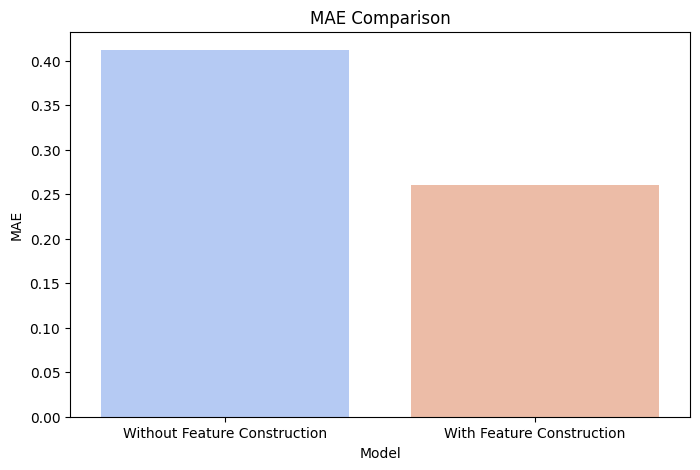

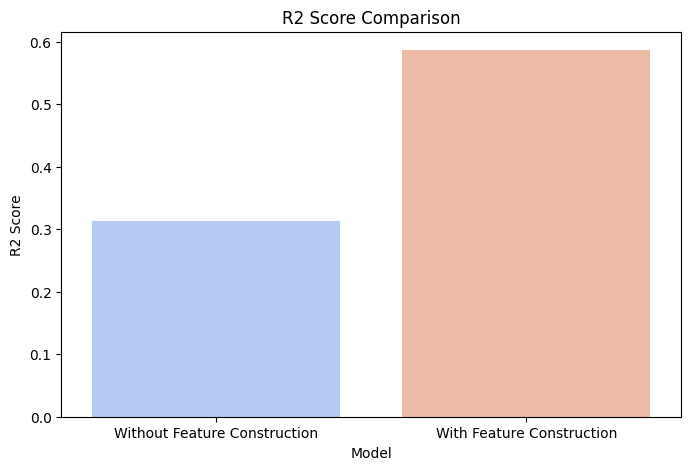

Performance Comparison:
                          Model       MAE  R2 Score
0  Without Feature Construction  0.412091  0.312501
1     With Feature Construction  0.260229  0.586546


In [24]:
plt.figure(figsize=(8, 5))
metrics_df = pd.DataFrame({
    "Model": ["Without Feature Construction", "With Feature Construction"],
    "MAE": [mae_without, mae_with],
    "R2 Score": [r2_without, r2_with]
})
sns.barplot(x="Model", y="MAE", data=metrics_df, palette="coolwarm")
plt.title("MAE Comparison")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=metrics_df, palette="coolwarm")
plt.title("R2 Score Comparison")
plt.show()

# Print results
print("Performance Comparison:")
print(metrics_df)

# Hyperparameter tuning for RandomForest

In [40]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 7]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_

In [41]:
best_rf_model

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [42]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 7]
}
grid_search2 = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search2.fit(X_train_new, y_train_new)
best_rf_model2 = grid_search.best_estimator_

In [43]:
best_rf_model2

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

# Train optimized RandomForest model

In [44]:
y_pred_rf = best_rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [29]:
mae_rf

0.265110115384615

In [45]:
r2_rf

0.3098588051952116

In [51]:
y_pred_rf2 = best_rf_model2.predict(X_test)
mae_rf2 = mean_absolute_error(y_test, y_pred)
r2_rf2 = r2_score(y_test, y_pred)

In [52]:
mae_rf2

0.41209123076923065

In [54]:
r2_rf2

0.31250065211129907

# Train Gradient Boosting model

In [34]:
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

In [35]:
mae_gb

0.28902283713814414

In [36]:
r2_gb

0.5627357728046931

In [33]:
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_new, y_train_new)
y_pred_gb = gb_model.predict(X_test_new)
mae_gb2 = mean_absolute_error(y_test_new, y_pred_gb)
r2_gb2 = r2_score(y_test_new, y_pred_gb)

In [37]:
mae_gb2

0.23677643060030734

In [38]:
r2_gb2

0.6539478517280926

# Visualization

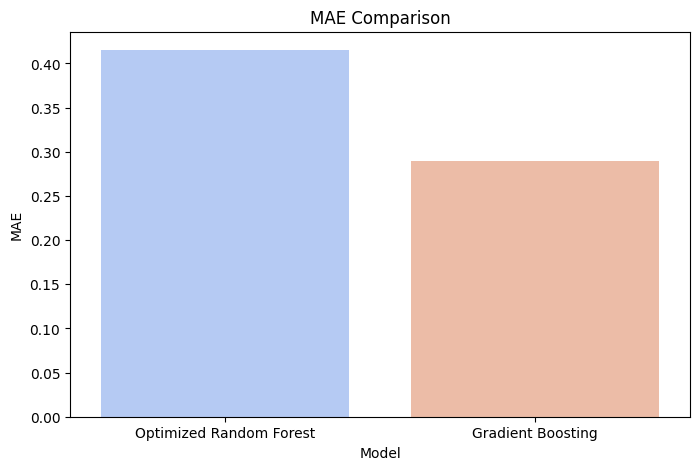

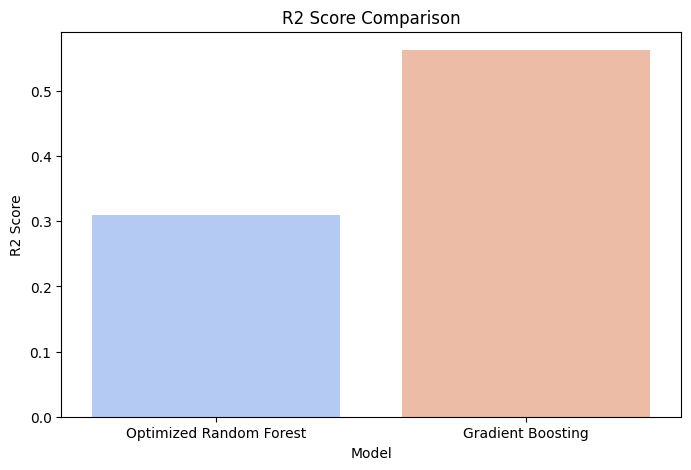

Final Performance Comparison:
                     Model       MAE  R2 Score
0  Optimized Random Forest  0.415157  0.309859
1        Gradient Boosting  0.289023  0.562736


In [55]:
metrics_df = pd.DataFrame({
    "Model": ["Optimized Random Forest", "Gradient Boosting"],
    "MAE": [mae_rf, mae_gb],
    "R2 Score": [r2_rf, r2_gb]
})

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="MAE", data=metrics_df, palette="coolwarm")
plt.title("MAE Comparison")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=metrics_df, palette="coolwarm")
plt.title("R2 Score Comparison")
plt.show()

# Print results
print("Final Performance Comparison:")
print(metrics_df)

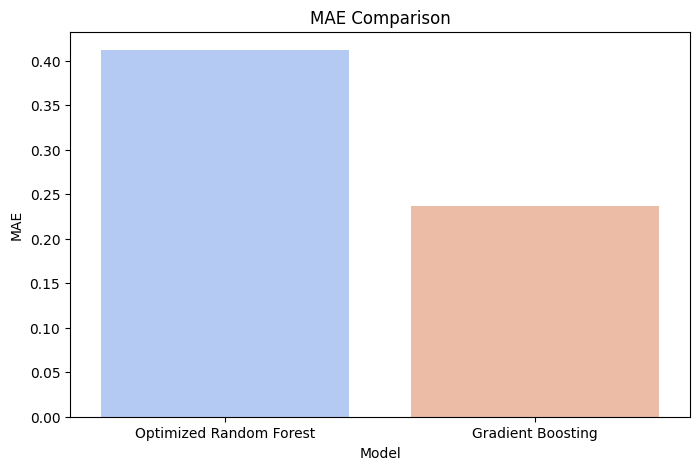

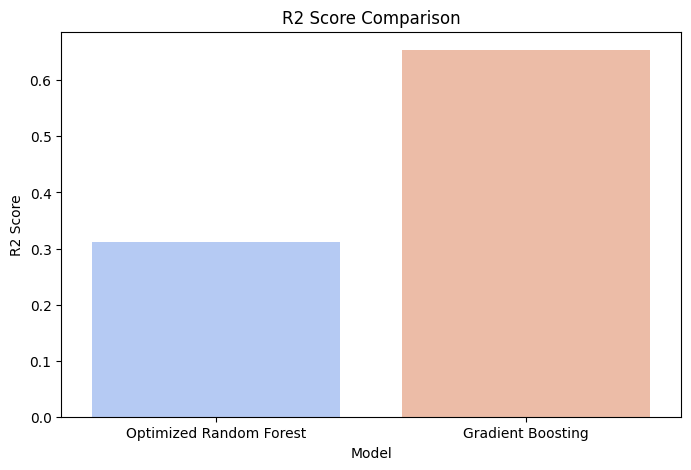

Final Performance Comparison:
                     Model       MAE  R2 Score
0  Optimized Random Forest  0.412091  0.312501
1        Gradient Boosting  0.236776  0.653948


In [56]:
metrics_df = pd.DataFrame({
    "Model": ["Optimized Random Forest", "Gradient Boosting"],
    "MAE": [mae_rf2, mae_gb2],
    "R2 Score": [r2_rf2, r2_gb2]
})

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="MAE", data=metrics_df, palette="coolwarm")
plt.title("MAE Comparison")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=metrics_df, palette="coolwarm")
plt.title("R2 Score Comparison")
plt.show()

# Print results
print("Final Performance Comparison:")
print(metrics_df)

# Polynomial Features

In [59]:
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(df.drop(columns=['CupEquivalentPrice']))

# Feature Scaling

In [61]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split again

In [62]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Cross-validation setup

In [66]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter tuning for Gradient Boosting

In [68]:
param_grid_gb = {
    'n_estimators': [200, 500],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 10]
}
grid_search_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=cv, scoring='r2')
grid_search_gb.fit(X_train, y_train)
best_gb_model = grid_search_gb.best_estimator_

# Train XGBoost model

In [71]:
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

In [72]:
mae_xgb

0.31655954370498657

In [73]:
r2_xgb

0.4896414471690994

# Train SVR model

In [74]:
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

In [75]:
mae_svr

0.3786817523482557

In [76]:
r2_svr

0.3127700514449061

# Evaluate best Gradient Boosting model

In [77]:
y_pred_gb4 = best_gb_model.predict(X_test)
mae_gb4 = mean_absolute_error(y_test, y_pred_gb4)
r2_gb4 = r2_score(y_test, y_pred_gb4)

In [78]:
mae_gb4

0.30243583750205594

In [79]:
r2_gb4

0.5188905305383065

# Visualization

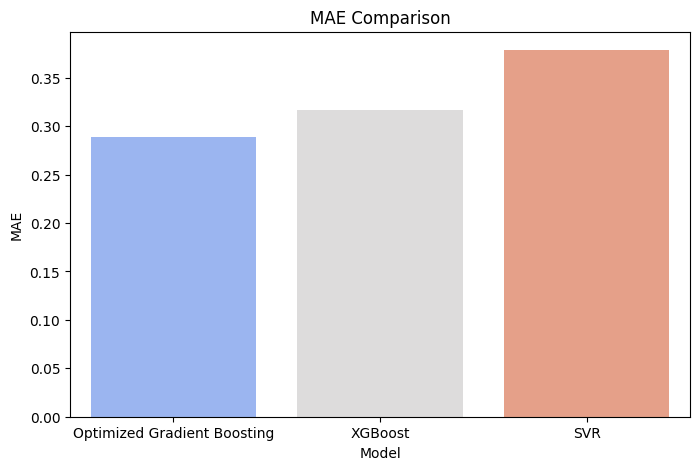

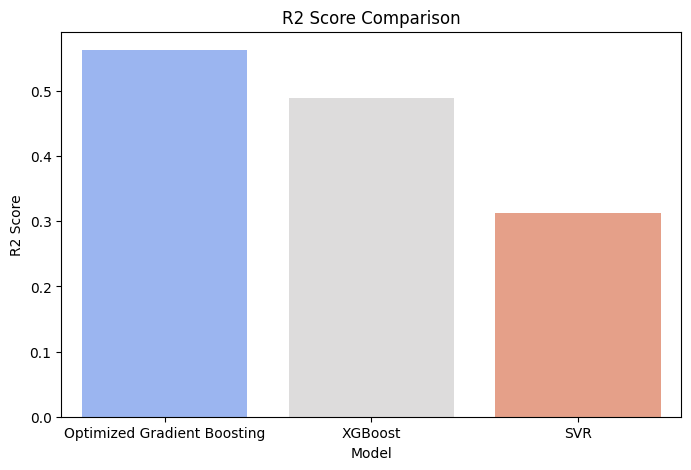

Final Performance Comparison:
                         Model       MAE  R2 Score
0  Optimized Gradient Boosting  0.289023  0.562736
1                      XGBoost  0.316560  0.489641
2                          SVR  0.378682  0.312770


In [80]:
metrics_df = pd.DataFrame({
    "Model": ["Optimized Gradient Boosting", "XGBoost", "SVR"],
    "MAE": [mae_gb, mae_xgb, mae_svr],
    "R2 Score": [r2_gb, r2_xgb, r2_svr]
})

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="MAE", data=metrics_df, palette="coolwarm")
plt.title("MAE Comparison")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=metrics_df, palette="coolwarm")
plt.title("R2 Score Comparison")
plt.show()

# Print results
print("Final Performance Comparison:")
print(metrics_df)

# Thank you